# Clase 2: Predicción de LTV y Toma de Decisiones Estratégicas con Regresión Lineal

**Duración:** 1 hora 30 minutos

**Módulo:** Identificación de variables clave de rentabilidad y segmentación de clientes

---

## Objetivos de la sesión

* Entender e interpretar los resultados del modelo de regresión lineal.
* Usar el modelo para predecir el LTV de nuevos clientes.
* Presentar resultados a equipos no técnicos y proponer acciones estratégicas basadas en el modelo.
* Desarrollar experiencia práctica construyendo y evaluando un modelo desde cero en equipos.

---

## 1. Cierre de la sesión anterior: Interpretación de resultados

* Repaso de la selección de variables y significancia estadística.
* Discusión sobre el signo e impacto de cada variable (coeficiente positivo/negativo).
* ¿Qué significa el R²? ¿Cómo saber si el modelo es útil?
* Identificación de sesgos o errores frecuentes (multicolinealidad, outliers, overfitting, etc.).

### Ejemplo de interpretación práctica:

* Una variable con coeficiente positivo aumenta el LTV esperado.
* Una variable con p-value alto no aporta valor al modelo y puede eliminarse.
* El R² representa la proporción de la varianza del LTV explicada por las variables seleccionadas.

In [20]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Cargar datasets
df_customers = pd.read_csv('data/tlacuachitos_express_customers_data.csv')
df_transactions = pd.read_csv('data/tlacuachitos_express_transactions.csv')

df_transactions['TransactionDate'] = pd.to_datetime(df_transactions['TransactionDate'])
df_customers['Cohort'] = pd.to_datetime(df_customers['Cohort'])

snapshot_date = df_transactions['TransactionDate'].max()

df_customers['customer_tenure'] = ((snapshot_date.year - df_customers['Cohort'].dt.year)*12 +
                                   (snapshot_date.month - df_customers['Cohort'].dt.month))

df_master = df_transactions.merge(df_customers, on='CustomerID')
df_master['customer_tenure_on_transaction'] = (
    (df_master['TransactionDate'].dt.year - df_master['Cohort'].dt.year)*12 +
    (df_master['TransactionDate'].dt.month - df_master['Cohort'].dt.month)
)

cltv_24_months = df_master[
    (df_master['customer_tenure_on_transaction'] <= 24)
].groupby('CustomerID')['TransactionAmount'].sum().reset_index()
cltv_24_months.rename(columns={'TransactionAmount': 'LTV'}, inplace=True)

# Variables categóricas a dummies
df_encoded = pd.get_dummies(df_customers, columns=['Education', 'Industry', 'Geographic Location'], drop_first=False, dtype=int)

# Unir con LTV
features_for_model = cltv_24_months.merge(df_encoded, on='CustomerID')
features_for_model['num_transactions'] = df_master[df_master['customer_tenure_on_transaction'] <= 24].groupby('CustomerID').size().values

numerical_features = ['Income', 'Age']
scaler = StandardScaler()
features_for_model[numerical_features] = scaler.fit_transform(features_for_model[numerical_features])


X = features_for_model.drop(['CustomerID', 'LTV', 'Cohort', 'num_transactions', 'Tenure', 'customer_tenure'], axis=1)
y = features_for_model['LTV']
X = sm.add_constant(X)

def stepwise_selection(X, y, threshold_out=0.05):
    while True:
        model = sm.OLS(y, X).fit()
        max_pval = model.pvalues.drop('const').max()
        if max_pval > threshold_out:
            worst_feature = model.pvalues.drop('const').idxmax()
            X = X.drop(worst_feature, axis=1)
        else:
            break
    return X, model

X_selected, final_model = stepwise_selection(X, y)
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    LTV   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     144.5
Date:                Thu, 07 Aug 2025   Prob (F-statistic):          2.65e-218
Time:                        16:09:25   Log-Likelihood:                -10316.
No. Observations:                1143   AIC:                         2.066e+04
Df Residuals:                    1130   BIC:                         2.072e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

---

## 2. Predicción de LTV para nuevos clientes

* ¿Cómo usar el modelo para clientes nuevos o escenarios "what-if"?

In [21]:
scaler.get_feature_names_out()

array(['Income', 'Age'], dtype=object)

In [29]:
# Supón que final_model es tu modelo entrenado y X_selected tiene las columnas finales
nuevo_cliente = {
    'const': 1,
    'Age': 29,
    'Income': 5000,
    'Education_Bachelor': 0,
    'Education_High School': 0,
    'Education_Master': 1,
    'Education_PhD': 0,
    'Industry_Finance': 0,
    'Industry_Education': 0,
    'Industry_Entertainment': 0,
    'Industry_Healthcare': 0,
    'Industry_Technology': 1,
    'Geographic Location_Europe': 0,
    'Geographic Location_South America': 0,
    'Geographic Location_Asia': 0,
    'Geographic Location_Australia': 0,
    'Geographic Location_North America': 1,
}
nuevo_cliente_df = pd.DataFrame([nuevo_cliente])[X_selected.columns]

In [30]:
nuevo_cliente_df[['Income', 'Age']] = scaler.transform(nuevo_cliente_df[['Income', 'Age']])
nuevo_cliente_df

,const,Age,Income,Education_Bachelor,Education_High School,Education_Master,Education_PhD,Industry_Entertainment,Industry_Finance,Industry_Technology,Geographic Location_Asia,Geographic Location_Australia,Geographic Location_Europe,Geographic Location_North America,Geographic Location_South America
0,1,-0.971381,-2.972713,0,0,1,0,0,0,1,0,0,0,1,0


In [31]:

prediccion = final_model.predict(nuevo_cliente_df)
print(f"Predicción de LTV para nuevo cliente: ${prediccion[0]:,.2f}")

Predicción de LTV para nuevo cliente: $6,335.68


* Simula la predicción para distintos perfiles y discute cómo cambia el resultado.

---

## 3. ¿Cómo comunicar y presentar el modelo?

* Cómo presentar resultados a dirección/marketing: claridad, gráficos, insights accionables.
* Visualizaciones:

  * Gráficas de importancia de variables.
  * Segmentación de clientes según el LTV predicho.
  * Top 5 recomendaciones para la toma de decisiones (¿qué clientes priorizar?).
* Precauciones y limitaciones del modelo.

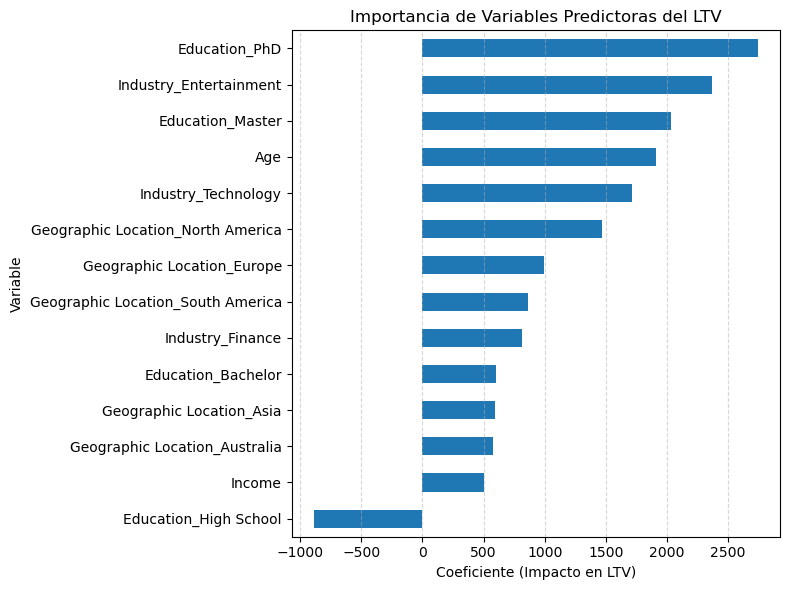

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Excluimos el intercepto para la gráfica
coefs = final_model.params.drop('const')

plt.figure(figsize=(8,6))
coefs.sort_values().plot(kind='barh')
plt.title('Importancia de Variables Predictoras del LTV')
plt.xlabel('Coeficiente (Impacto en LTV)')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

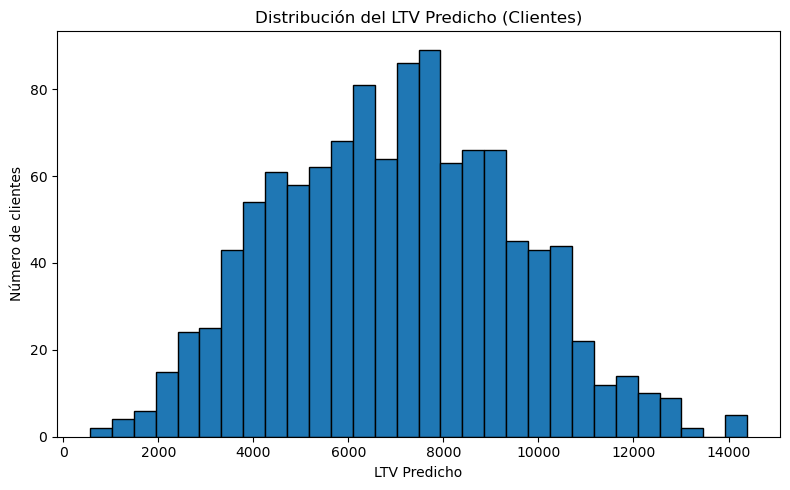

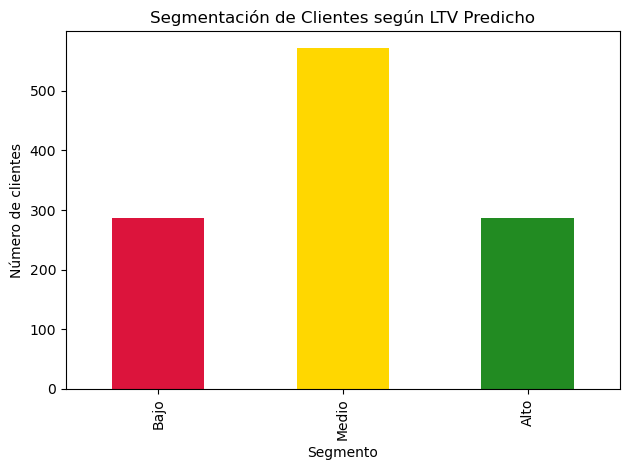

In [33]:
# Agrega la columna de predicción de LTV al dataframe original
features_for_model['LTV_predicho'] = final_model.predict(X_selected)

plt.figure(figsize=(8,5))
plt.hist(features_for_model['LTV_predicho'], bins=30, edgecolor='black')
plt.title('Distribución del LTV Predicho (Clientes)')
plt.xlabel('LTV Predicho')
plt.ylabel('Número de clientes')
plt.tight_layout()
plt.show()

# Ejemplo de segmentación: cuartiles (top 25%, medio, bajo)
features_for_model['segmento'] = pd.qcut(features_for_model['LTV_predicho'], 
                                         q=[0, .25, .75, 1], 
                                         labels=['Bajo', 'Medio', 'Alto'])
segment_counts = features_for_model['segmento'].value_counts().sort_index()
segment_counts.plot(kind='bar', color=['crimson', 'gold', 'forestgreen'])
plt.title('Segmentación de Clientes según LTV Predicho')
plt.xlabel('Segmento')
plt.ylabel('Número de clientes')
plt.tight_layout()
plt.show()

---

## 4. Actividad práctica en equipos: "Construye tu propio modelo de regresión"

* Forma equipos de 3-4 personas.
* Cada equipo debe:

  1. Seleccionar variables relevantes.
  2. Limpiar y preparar los datos.
  3. Ajustar un modelo de regresión lineal desde cero (usando statsmodels/sklearn).
  4. Interpretar sus resultados y presentar una recomendación estratégica (¿a quiénes priorizar?).
  5. Preparar una gráfica para presentar.

### Sugerencia de flujo para el ejercicio:

1. Explora y selecciona las variables que usarás (usa sólo las que el equipo considere relevantes).
2. Prepara los datos (quita nulos, convierte categóricas a dummies, etc.).
3. Ajusta un modelo lineal, revisa los coeficientes y el R².
4. Haz una predicción de LTV para un nuevo cliente que inventen.
5. Presenta los resultados de tu modelo a la clase (en máximo 5 minutos por equipo).



---

## 5. Reflexión final y discusión grupal

* ¿Qué aprendiste sobre la interpretación y aplicación de modelos de regresión?
* ¿Qué limitaciones observaste?
* ¿Cómo aplicarías este enfoque a otros KPIs o problemas de negocio?

---

## Recursos y documentación recomendada

* [Interpretación de modelos en Python - statsmodels](https://www.statsmodels.org/stable/examples/notebooks/generated/ols.html)
* [Presentación de resultados de análisis de datos](https://realpython.com/python-data-visualization-beginners/)
